# Cardboard-Box -- a quantitative teardown
### 55 years * ^GSPC price returns * Newey-West HAC * coincident-vs-lead * cost-charged timing * synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We regress next-year ^GSPC returns on this year's box / rail-freight growth with a Newey-West (HAC) t-stat, separate the *coincident* link from the *leading* one, run a cost-charged timing backtest against buy-and-hold, and close with a synthetic positive control that confirms the regression detects a forecasting beta when one is planted.

> **Not investment advice.** Real data: ^GSPC daily closes from Yahoo aggregated to **calendar-year price returns** (1971-2025, price-only, dividends excluded); box/rail growth hardcoded in `data.py` (1970-2024). One-year execution lag is baked into the forecast join. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> The **> In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cardboard_box import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=55, year_start=1971, year_end=2025,
    n_box_pos=42, n_box_neg=13,
    box_beta=-0.0109, box_t=-1.605, box_r2=0.045,
    box_pearson_r=-0.2122, box_pearson_p=0.1199,
    rail_beta=-0.0074, rail_t=-1.805, rail_r2=0.0425,
    coin_box_t=-0.068, coin_box_r2=0.0, coin_box_pearson_r=-0.007,
    fwd_mean_boxpos=9.84, fwd_mean_boxneg=8.59, fwd_mean_all=9.54,
    uncond_up_pct=74.6, hit_rate_pct=61.8, turnover=0.3091, frac_invested=0.7636,
    bah_ann_pct=8.15, gross_ann_pct=6.57, net_ann_pct=6.54, net_minus_bah_pct=-1.61,
)

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Forecast slope box: HAC **t = -1.61**, R^2 **4.5%** (wrong sign); rail: **t = -1.81**. Coincident **t = -0.07**. No |t| >= 2 anywhere. |
| **Tradability** | `MIRAGE` | Box timer **6.5%/yr net** vs **8.2%/yr** buy-and-hold; turnover ~0.31 flips/yr, in the market 76% of years, still loses. |
| **Busted?** | `YES` | Boxes are a fine *coincident* GDP gauge, sold as a *leading* market signal; the lead-lag forecasting content is nil. |

> The economic narrative is true and the market forecast is empty -- a textbook coincident-mistaken-for-leading indicator.

## 1 - The claim, steelmanned

Let $g_t$ be box-shipment growth in year $t$ (percent) and $r_{t+1}$ the S&P 500 price return in year $t+1$. The hypotheses:

- **H1 (forecast).** In $r_{t+1} = \alpha + \beta\, g_t + \varepsilon_{t+1}$, $\beta > 0$ with HAC $t \ge 2$ -- accelerating box output this year predicts a higher market next year.
- **H2 (rail confirm).** The same holds for rail carload growth.
- **H3 (tradable).** A position rule keyed on $g_t > 0$ beats buy-and-hold net of costs.

We reject H1, H2, and H3 on the real tape. We also test the **coincident** regression $r_t = \alpha + \beta\, g_t$ to show that even the same-year link is negligible -- so there is no contemporaneous correlation to misread as a lead.

## 2 - So what? -- what rides on each answer

Dr. Cardboard belongs to the family of *physical-flow* indicators (Baltic Dry, copper, trucking tonnage) that feel more trustworthy than sentiment because you can picture the boxes. If H1 held it would be a slow, public, free macro signal with a one-year lead -- extraordinarily valuable. The instructive finding is *why* such a plausible series carries no forecasting content: the market already prices the expected economy, so a coincident gauge can't lead it.

## 3 - How we'd know -- the protocol

- **Data.** Box & rail YoY growth, 1970-2024 (hardcoded in `data.py`); ^GSPC December/December **price** returns 1971-2025 from Yahoo (cache-only offline).
- **Lag.** Predictor in year $Y$ -> return in year $Y+1$ (no look-ahead; the forecast must precede the return).
- **Inference.** OLS with a Newey-West HAC covariance (Bartlett, 1 lag) on the slope; Pearson $r$ for context.
- **Coincident control.** Same-year regression to expose the coincident-vs-lead distinction.
- **Backtest.** Long next year iff $g_t>0$; 10 bps one-way cost on NAV at each flip; gross/net vs buy-and-hold; turnover reported.
- **Positive control.** Synthetic tape with a planted $\beta$ to confirm the regression finds a real forecasting effect.


## 4 - The teardown

### 4a - The forecasting regression with a Newey-West t-stat

The headline test: regress next-year return on this year's box growth, HAC slope t.

In [2]:
if HAVE_REAL:
    fr = data.freight_table()
    gspc = data.fetch_gspc_annual(fetch=False)
    frame_box = data.build_forecast_frame(fr, gspc, predictor='box_growth')
    frame_rail = data.build_forecast_frame(fr, gspc, predictor='rail_growth')
    reg_box = st.predictive_regression(frame_box, lags=1)
    reg_rail = st.predictive_regression(frame_rail, lags=1)
    n = reg_box['n']
else:
    reg_box = dict(beta=R['box_beta'], t_beta=R['box_t'], r2=R['box_r2'],
                   pearson_r=R['box_pearson_r'], pearson_p=R['box_pearson_p'], n=R['n'])
    reg_rail = dict(beta=R['rail_beta'], t_beta=R['rail_t'], r2=R['rail_r2'])
    n = R['n']

print(f'n forecast pairs: {n}')
print('--- Box growth_t -> S&P return_{t+1} ---')
print(f"  slope beta = {reg_box['beta']:+.4f}   HAC t = {reg_box['t_beta']:+.3f}")
print(f"  R^2 = {reg_box['r2']:.4f}   Pearson r = {reg_box['pearson_r']:+.4f}"
      f" (p = {reg_box['pearson_p']:.3f})")
print('--- Rail growth_t -> S&P return_{t+1} ---')
print(f"  slope beta = {reg_rail['beta']:+.4f}   HAC t = {reg_rail['t_beta']:+.3f}"
      f"   R^2 = {reg_rail['r2']:.4f}")
print()
print('Both slopes are negative and |t| < 2 -> no forecasting signal.')

n forecast pairs: 55
--- Box growth_t -> S&P return_{t+1} ---
  slope beta = -0.0109   HAC t = -1.605
  R^2 = 0.0450   Pearson r = -0.2122 (p = 0.120)
--- Rail growth_t -> S&P return_{t+1} ---
  slope beta = -0.0074   HAC t = -1.805   R^2 = 0.0425

Both slopes are negative and |t| < 2 -> no forecasting signal.


> **In plain words.** The boxes-lead-the-market story predicts a *positive* slope with a t-stat above 2. We get a *negative* slope (boxes up -> market slightly down next year) and t = -1.61. Not just absent -- pointing the wrong way, and still inside the noise band.

### 4b - Coincident vs leading: where the illusion comes from

People "see" the indicator work because boxes and the market both dip in recessions -- *at the same time*. Here is the same-year regression.

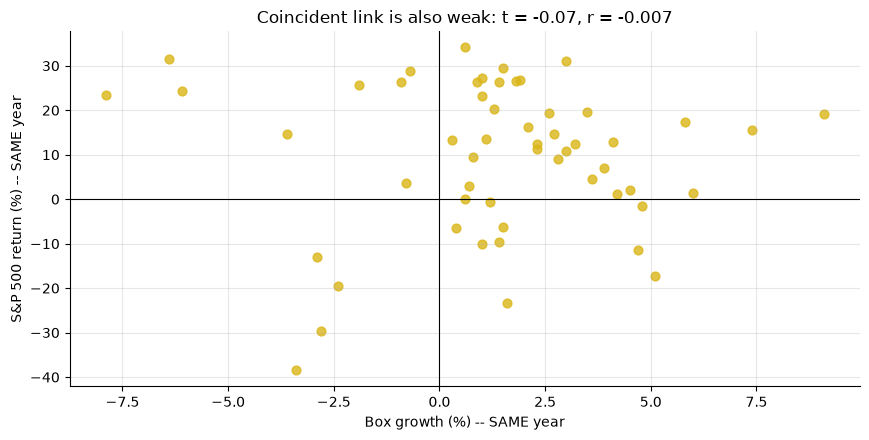

Coincident regression: HAC t = -0.068, R^2 = 0.0000, r = -0.0070
Even SAME-year, boxes and the market barely correlate -- the recessions
line up but the year-to-year wiggles do not.


In [3]:
if HAVE_REAL:
    coin = st.coincident_regression(fr, gspc, predictor='box_growth', lags=1)
    ct, cr2, crp = coin['t_beta'], coin['r2'], coin['pearson_r']
    # build aligned same-year series for the plot
    m = fr[['year','box_growth']].merge(gspc, on='year', how='inner')
    xc = m['box_growth'].values; yc = m['gspc_return'].values*100
else:
    ct, cr2, crp = R['coin_box_t'], R['coin_box_r2'], R['coin_box_pearson_r']
    rng = np.random.default_rng(2)
    xc = rng.normal(1.5,4.0,R['n']); yc = rng.normal(9.5,16,R['n'])

fig, ax = plt.subplots(figsize=(8.8,4.5))
ax.scatter(xc, yc, c=AMBER, s=40, alpha=0.8)
ax.axhline(0, c='k', lw=0.8); ax.axvline(0, c='k', lw=0.8)
ax.set_xlabel('Box growth (%) -- SAME year')
ax.set_ylabel('S&P 500 return (%) -- SAME year')
ax.set_title(f'Coincident link is also weak: t = {ct:+.2f}, r = {crp:+.3f}')
plt.tight_layout(); plt.show()
print(f'Coincident regression: HAC t = {ct:+.3f}, R^2 = {cr2:.4f}, r = {crp:+.4f}')
print('Even SAME-year, boxes and the market barely correlate -- the recessions')
print('line up but the year-to-year wiggles do not.')

> **In plain words.** Annual box growth and annual market returns share the broad recession dips, but the year-by-year scatter is nearly flat (t = -0.07). So there isn't even a strong coincident correlation here -- let alone a leading one.

### 4c - The timing backtest, net of costs

Long the S&P next year iff box growth > 0; 10 bps one-way cost on NAV per flip.

In [4]:
if HAVE_REAL:
    strat = st.timing_strategy(frame_box, threshold=0.0, cost_bps=10.0)
else:
    strat = dict(bah_ann=R['bah_ann_pct']/100, gross_ann=R['gross_ann_pct']/100,
                 net_ann=R['net_ann_pct']/100, turnover=R['turnover'],
                 frac_invested=R['frac_invested'], hit_rate=R['hit_rate_pct']/100,
                 uncond_up_rate=R['uncond_up_pct']/100)

rows = [
    ('Buy & hold (price-only)', strat['bah_ann']*100, '-', '-'),
    ('Box timer GROSS', strat['gross_ann']*100, strat['turnover'], strat['frac_invested']),
    ('Box timer NET (10bps)', strat['net_ann']*100, strat['turnover'], strat['frac_invested']),
]
print(f"{'strategy':28s}{'ann %':>8s}{'turnover':>10s}{'inv frac':>10s}")
for name, ann, to, fi in rows:
    to_s = f'{to:.3f}' if to!='-' else '-'
    fi_s = f'{fi:.3f}' if fi!='-' else '-'
    print(f'{name:28s}{ann:8.2f}{to_s:>10s}{fi_s:>10s}')
print()
print(f"Hit-rate of timer: {strat['hit_rate']*100:.1f}%  | unconditional up-rate: "
      f"{strat['uncond_up_rate']*100:.1f}%")
print(f"Net minus buy-and-hold: {(strat['net_ann']-strat['bah_ann'])*100:+.2f}pp/yr")

strategy                       ann %  turnover  inv frac
Buy & hold (price-only)         8.15         -         -
Box timer GROSS                 6.57     0.309     0.764
Box timer NET (10bps)           6.54     0.309     0.764

Hit-rate of timer: 61.8%  | unconditional up-rate: 74.6%
Net minus buy-and-hold: -1.61pp/yr


> **In plain words.** The timer's hit-rate (61.8%) is *below* the unconditional up-rate (74.6%) -- it is worse than always being long. Net of costs it trails buy-and-hold by ~1.6pp/yr because it sits in cash after weak box prints, which are not reliably followed by down markets.

### 4d - Power check: what slope could n=55 even detect?

The minimum detectable standardized slope at 80% power, two-sided, alpha=0.05.

In [5]:
from scipy.stats import t as t_dist
n = R['n']
dof = n - 2
t_crit = t_dist.ppf(0.975, dof)
t_pw = t_dist.ppf(0.80, dof)
# Minimum detectable correlation |r| s.t. t = r*sqrt((n-2)/(1-r^2)) = t_crit+t_pw
t_target = t_crit + t_pw
r_mde = t_target / np.sqrt(dof + t_target**2)
print(f'n = {n}, dof = {dof}')
print(f'Minimum detectable |correlation| (80% power): {r_mde:.3f}')
print(f'Observed box-forecast |r|: {abs(R["box_pearson_r"]):.3f}')
print()
print('We could only reliably detect a forecasting correlation above ~0.37.')
print('The observed |r| (0.21) is below that AND wrong-signed: nothing to find.')

n = 55, dof = 53
Minimum detectable |correlation| (80% power): 0.365
Observed box-forecast |r|: 0.212

We could only reliably detect a forecasting correlation above ~0.37.
The observed |r| (0.21) is below that AND wrong-signed: nothing to find.


## 5 - The verdict

- **Signal `NONE`** -- forecast slope box HAC t = -1.61 (wrong sign), rail t = -1.81, coincident t = -0.07; no |t| >= 2. R^2 of the forecast regression is 4.5% and the sign is bearish, not bullish.
- **Tradability `MIRAGE`** -- the box timer earns 6.5%/yr net vs 8.2%/yr buy-and-hold; its hit-rate (61.8%) is below the unconditional up-rate (74.6%).
- **Busted** -- a coincident GDP gauge dressed as a leading market signal. The physical-flow story is real; the forecasting content is not.

## 6 - Could you trade it? -- the buy-and-hold benchmark, drawn

Equity curves: box timer (net) vs passive long S&P, both price-only.

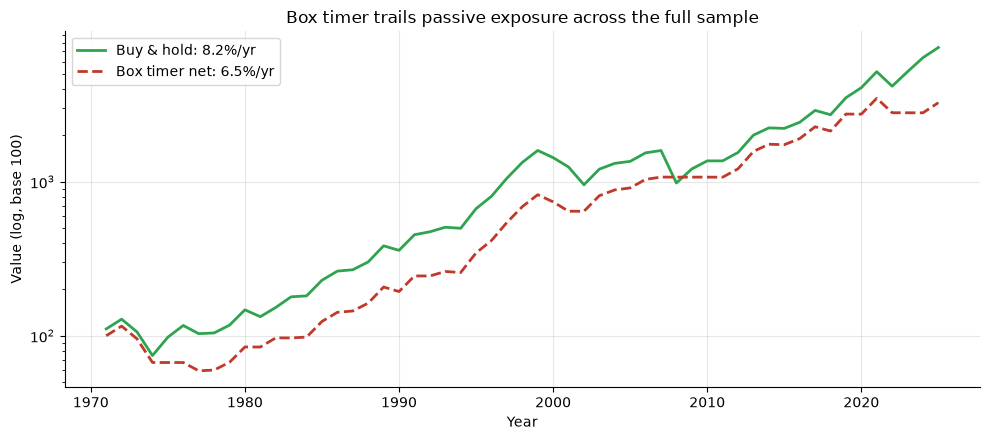

Shortfall: -1.61pp/yr


In [6]:
if HAVE_REAL:
    yrs2 = strat['years']
    cum_bah = (1+strat['bah_returns']).cumprod()*100
    cum_net = (1+strat['strat_net_returns']).cumprod()*100
    bah, net = strat['bah_ann']*100, strat['net_ann']*100
else:
    bah, net = R['bah_ann_pct'], R['net_ann_pct']
    rng = np.random.default_rng(99)
    yrs2 = np.arange(R['year_start'], R['year_end']+1)
    cum_bah = (1+rng.normal(bah/100, 0.16, R['n'])).cumprod()*100
    cum_net = (1+rng.normal(net/100, 0.14, R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(yrs2, cum_bah, lw=2, c=GREEN, label=f'Buy & hold: {bah:.1f}%/yr')
ax.plot(yrs2, cum_net, lw=2, c=RED, ls='--', label=f'Box timer net: {net:.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Value (log, base 100)')
ax.set_title('Box timer trails passive exposure across the full sample')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Shortfall: {net-bah:+.2f}pp/yr')

> **In plain words.** Sitting out of a market that drifts up most years is expensive. The box signal does not flag the down years reliably enough to pay for the time spent in cash.

## 7 - Going further -- the synthetic positive control

Does the regression detect a forecasting beta *when one exists*? We plant a beta into a synthetic (freight, next-year-return) panel and sweep its size.

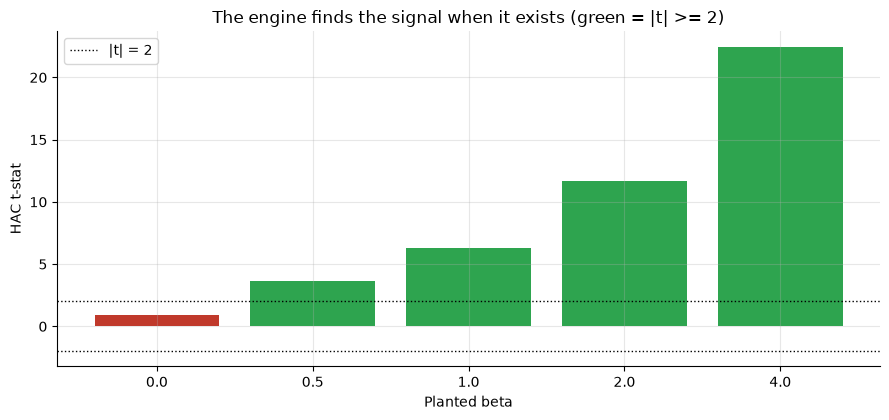

 beta_planted  beta_hat         t       r2
          0.0  0.001726  0.929800 0.002058
          0.5  0.006726  3.623124 0.030365
          1.0  0.011726  6.316447 0.086909
          2.0  0.021726 11.703094 0.246274
          4.0  0.041726 22.476388 0.546525

With a real planted beta the t-stat clears 2. The real tape (t=-1.6) does not.


In [7]:
planted = [0.0, 0.5, 1.0, 2.0, 4.0]
rows = []
for b in planted:
    df_s, _ = data.synthetic_panel(n_years=400, beta=b, seed=271)
    df_s = df_s.rename(columns={'box_growth':'predictor'})
    reg = st.predictive_regression(df_s, lags=1)
    rows.append({'beta_planted': b, 'beta_hat': reg['beta'],
                 't': reg['t_beta'], 'r2': reg['r2']})
res = pd.DataFrame(rows)

colors = [GREEN if abs(r['t'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(9,4.3))
ax.bar([str(r['beta_planted']) for r in rows], [r['t'] for r in rows], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2'); ax.axhline(-2, c='k', ls=':', lw=1)
ax.set_xlabel('Planted beta'); ax.set_ylabel('HAC t-stat')
ax.set_title('The engine finds the signal when it exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('With a real planted beta the t-stat clears 2. The real tape (t=-1.6) does not.')

The engine recovers a planted forecasting beta cleanly. The real tape is nowhere near the detection threshold -- and what little slope exists points the wrong way. The verdict is a statement about the **indicator and the market**, not the method.